 # Preprocess SuperCon
 * Using 145 features of Matminer + XGBoost Regressor
 * Raw SuperCon dataset:
     * Center for Basic Research on Materials. (n.d.). MDR SuperCon Datasheet Ver.240322. National Institute for Materials Science.
     * https://doi.org/10.48505/nims.4487
     * `20240322_MDR_OAndM.txt`: Oxides and Metallic
 * Description(PDF): https://mdr.nims.go.jp/filesets/4f1fcd20-92ea-4b53-8c2d-29281d2ca642/download
     * *Tc* columns (in abbreviation name):
         * `tc`---Tc (of this sample) recommended---: It is considered as a representative T_c if exist.
         * `tc1`, `tc2`, `tc3`: Resistivity zero, 50% (mid point), 100%(onset)
         * `tcsus`: Tc measured from susceptibility measurement
         * `tcn`: lowest temperature for measurement (not superconducting)
         * `tcmeth`: tc measurement method (1.magnetization, 2.ac susceptibility, 3.resistivity, 4.heat capacity, 5.tunneling, 6.infrared spectroscopy, 7.thermal conductivity, 8.Raman spectroscopy , 9.nuclear magnetic resonance, 10.surface impedance, 11.neutron diffraction, 12.photoemission spectroscopy, 13.microwave transmission, 14.Others)
     * compositions and fractions:
         * on the column names, ignore the number following `element name of materials`.
             * like `element name of materials.1`
             * As they are just assigned to avoid duplicate column names.
         * For Example, $Ba_{0.1}La_{1.9}Ag_{0.1}Cu_{0.9}O_{4-Y}$
             * `ma1` (element name of materials): 'Ba'
             * `ma2` (composition of MA1): 0.1
             * `mb1` (element name of materials.1): 'La'
             * `mb2` (composition of MA2): 1.9
             * `mc1` (element name of materials.2): 'Ag'
             * `mc2` (composition of MA3): 0.1
             * `md1`: ...
 ## identifier and formula (string)
   * all entry have a unique `data number`
   * all entries have `chemical formula`
 * OLD version uses Stanev et al. file.
     * See [preprocess_supercon.md](..\src\hsdu\data\miscs\preprocess_supercon.md)
     * See [preprocess_supercon.py](..\src\hsdu\data\miscs\preprocess_supercon.py)

In [18]:
import pandas as pd
import numpy as np

import re
from warnings import warn
from pymatgen.core.periodic_table import Element
from pymatgen.core import Composition


def validate_elements(elems)->tuple[list|None, list]:
    """
    return: tuple[
            * list(elements_corrected) | None
                * None if failed to correct elements
            * list(exceptions)
        ]
    """
    exceptions=[]
    try:
        [Element(el) for el in elems]
        return elems, None
    except ValueError:
        new_elems = []
        for el in elems:
            if el.rstrip() != el:
                el = el.rstrip()
                exceptions.append('trail_white')
                
            if len(el)==2 and isinstance(el, str) and el[1].isupper():
                el=el[0]+el[1].lower()
                exceptions.append('two_upper_letter_el')
            
            new_elems.append(el)
        
        if len(new_elems)==0:
            exceptions.append('no_valid_element')
        
        if exceptions:
            return new_elems, exceptions
        else:
            return None, exceptions
        
def fix_fracs(fracs)->tuple[list[float], list[str]]:
    """
    return: tuple[list[float], list[str]]
        * fixed fractions: list[float]
        * exceptions_to_drop: list[str]
    """
    new_fracs = []
    exceptions_to_drop = [] #exceptions to drop.
    for fr in fracs:
        if isinstance(fr, str):
            try:
                new_fracs.append(float(eval(fr)))
                # eval(fraction_string) worked
            except NameError:
                variable_in_fraction = re.search(r'[XxYyZzDd]', fr)
                if variable_in_fraction is not None:
                    # checkout only if it is a valid expression
                    eval_variable = re.sub(r'[XxYyZzDd]', '0.1', fr)
                    try:
                        float(eval(eval_variable))
                        exceptions_to_drop.append('equation_like_valid')
                        break
                    except ValueError:
                        exceptions_to_drop.append('equation_like_invalid')
                        break
                else:
                    try:
                        new_fracs.append(float(fr))
                    except ValueError:
                        exceptions_to_drop.append('NameError_float(fr)')
                        warn(f'cannot parse {i}: (NameError) {row[comp_cols]}', UserWarning)
                        break
            except TypeError as et:
                if not exceptions_to_drop and re.search(r'(?<=\d),(?=\d)', fr):
                    new_fracs.append(float(fr.replace(',','.'))) # comma -> period
                else:
                    raise et
            except SyntaxError:
                exceptions_to_drop.append('SyntaxError')
                warn(f'cannot parse {i} (SyntaxError): {row[comp_cols]}', UserWarning)
                break
        else:
            new_fracs.append(fr)
    
    non_zero_fracs = [fr for fr in fracs if fr!=0]
    assert len(new_fracs)==len(non_zero_fracs) or exceptions_to_drop
    return new_fracs, exceptions_to_drop

def validate_fracs(elems, fracs)->tuple[Composition | None, list]:
    """
    return: 
        * pymatgen_comps: Composition() object(from pymatgen.core).
        * exceptions_to_drop: log, reason to drop. notes.
    """
    exceptions_to_drop=[]

    try:
        comps={el:float(fr) for el, fr in zip(elems, fracs) if pd.notna(el)}
        pymatgen_comps=Composition(comps)

    except ValueError:
        new_fracs, exceptions_fracs =fix_fracs(fracs)
                
        if exceptions_fracs:
            pymatgen_comps=None
            warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
            exceptions_to_drop.append('invalid_frac')          
        
        else:
            try:
                comps={el:float(fr) for el, fr in zip(elems, new_fracs) if pd.notna(el)}
                pymatgen_comps=Composition(comps)
            except ValueError:
                pymatgen_comps=None
                exceptions_to_drop.append('others')
                warn(f'cannot parse {i}:{row[comp_cols]}', UserWarning)
    if not exceptions_to_drop and len(elems)!=len(pymatgen_comps):
        exceptions_to_drop.append(f'len(elems):len({elems})!=len(pymatgen_comps):len({pymatgen_comps})')
        warn(f'index {i}: len(elems):len({elems})!=len(pymatgen_comps):len({pymatgen_comps}', UserWarning)
        return None, exceptions_to_drop
    else:
        return pymatgen_comps, exceptions_to_drop

def elements_set_key(comp: Composition, sep: str='-')->str:
        """ return `elements-set-key` string of the comp for grouping,
        unique for the set of constituent elements (regardless of stoichiometry)
        
        args:
            * comp: Composition from pymatgen.core
            * sep: separator between elemental symbols. default '-'.
            
        return: 
            * elements-set-key, element symbols are ordered in IUPAC order.
        """
        elements = comp.elements
        sorted_elems = sorted(elements, key=lambda x: x.iupac_ordering)
        sorted_symbols = [el.symbol for el in sorted_elems]
        return sep.join(sorted_symbols)

In [19]:
if __name__=="__main__":
    # 20240322 MDR Oxides and M
    print("loads raw data '20240322_MDR_OAndM.txt' as as a pd.DataFrame")
    
    #your path to hsdu pacakge or 20240322_MDR_OAndM.txt from MDR SuperCon
    #### replace it to yours ####
    supercon_raw = r'../src/hsdu/data/miscs/20240322_MDR_OAndM.txt' 
    data=pd.read_csv(supercon_raw, sep='\t')

    # drop full column names, use abbreviations.
    col_abbreviation=data.loc[0]
    data = data.rename(columns={k:v for k, v in col_abbreviation.items()})
    data.drop(index=0, inplace=True)

loads raw data '20240322_MDR_OAndM.txt' as as a pd.DataFrame


/tmp/ipykernel_1716/4114936352.py:8: DtypeWarning: Columns (0,6,8,10,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,59,61,62,63,64,65,66,67,68,69,70,71,72,73,76,77,78,79,80,81,82,84,86,87,88,89,90,91,92,94,95,96,97,98,99,100,101,104,105,106,107,108,109,110,112,113,114,115,117,120,121,122,125,126,127,128,129,130,131,132,133,134,136,137,139,140,141,143,144,145,146,147,148,149,150,151,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,174,175,176,177,179,180,181,182,184,190) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(supercon_raw, sep='\t')


 # Preview the Dataset
 * Among the columns seems to be useful,
 * examine how many values available.

In [20]:
composition_cols = ['element name of materials', 'composition of MA1', 'element name of materials.1', 'composition of MA2', 'element name of materials.2', 'composition of MA3', 'element name of materials.3', 'composition of MA4', 'element name of materials.4', 'composition of MA5', 'element name of materials.5', 'composition of MA6', 'element name of materials.6', 'composition of MA7', 'element name of materials.7', 'composition of MA8', 'element name of materials.8', 'composition of MA9', 'element name of materials.9', 'composition of MA10', 
                    'oxygen', 'common formula of oxygen', 'measured value of Oxygen content']
comp_cols = [col_abbreviation[k] for k in composition_cols]
name_cols = ['data number', 'reference number', 'comment', 'common formula of materials', 'chemical formula', 'common name of structure']
name_cols = [col_abbreviation[k] for k in name_cols]

# tc_values:
tc_values=['transition temperature (R = 0)', 'transition temperature (mid point)', 'transition temperature (R = 100%)', 'Tc from susceptibility measurement', 'Tc (of this sample) recommended']
tc_values=[col_abbreviation[k] for k in tc_values]
tc_misc = ['unit of Tc', 'figure number for Tc(p, x, etc)', 'tc measurement method', 'transition width for resistive transition', 'lowest temperature for measurement (not superconducting)']
tc_misc = [col_abbreviation[k] for k in tc_misc]

In [21]:
print("##### Checkout available (not missing) values: #####")
print(data[comp_cols].describe())

##### Checkout available (not missing) values: #####
          ma1      ma2    mb1      mb2    mc1  ...  mj1  mj2    mo1    mo2      oz
count   33458  33458.0  33018  33003.0  26737  ...    1  1.0  17399  16727  4789.0
unique     91   1261.0     94   1337.0     87  ...    1  1.0      1    488  1344.0
top         Y      1.0     Ba      2.0     Cu  ...   Pb  1.0      O      z     4.0
freq     4487  11216.0   5805   6249.0   6828  ...    1  1.0  17399   2221   207.0

[4 rows x 23 columns]


 ## Tc values
 Among 33458 entries--
 * `tc`: 26358
 * `tc2`: 17117
 * `tcsus`: 5624
 * `tc1`, `tc3`: only 4051 and 4060 entries have, among 33458 entries.
 * `tcn`: 4641 (lowest temperature for measurment)
 * `utc` (unit of Tc): 24166 `K` and 1 `k`. just typo
 * others too few

In [22]:
data[tc_values+tc_misc].describe()

,t1,t2,t3,tcsus,tc,utc,tcfig,tcmeth,tcwidth,tcn
count,4051.0,17117.0,4606.0,5624.0,26358.0,24167,2045,744,1354.0,4641.0
unique,1396.0,3232.0,1426.0,1409.0,3869.0,2,1636,13,313.0,207.0
top,80.0,6.0,40.0,80.0,80.0,K,159020fig2,R,0.2,4.2
freq,36.0,79.0,52.0,58.0,141.0,24166,11,181,58.0,497.0


In [23]:
data['utc'].value_counts()

utc
K    24166
k        1
Name: count, dtype: int64

In [24]:
# the case unit of Tc=`k`
print(f"{data[data['utc']=='k'][tc_values+tc_misc]=}")

data[data['utc']=='k'][tc_values+tc_misc]=        t1   t2   t3 tcsus   tc utc tcfig tcmeth tcwidth  tcn
30442  9.2  NaN  NaN   NaN  9.2   k   NaN    NaN     NaN  NaN


 # Validate Tc values
 * preprocess: if `tcn` or `tc` values are 0, remove. It cannot be zero.
 * exceptional cases:
     1. If both `tcn` and valid `tc` exist
         1. if `tcn`>=`tc`, it might be the onset temperature
         1. if `tcn`<`tc`, it might be the baes temperature, lowest temperature reached on the measurment.
     1. If both `tcn` and valid `tc` missing: It is useless!

In [25]:
print("start processing Tc value")
# remove all tcn==0
print(f"remove {len(data.loc[data['tcn']==0])} tcn values that was 0.")
data.loc[data['tcn']==0, 'tcn']=np.nan
assert len(data.loc[data['tcn']==0])==0

start processing Tc value
remove 483 tcn values that was 0.


In [26]:
# zero tc values to be removed(it cannot be zero)
for tc_col in tc_values:
    print(f'removing 0 tc in {tc_col=} (number of zero tc values: {len(data.loc[data[tc_col]==0])})')
    data.loc[data[tc_col]==0, tc_col]=np.nan
    assert len(data.loc[data[tc_col]==0])==0

removing 0 tc in tc_col='t1' (number of zero tc values: 17)
removing 0 tc in tc_col='t2' (number of zero tc values: 40)
removing 0 tc in tc_col='t3' (number of zero tc values: 19)
removing 0 tc in tc_col='tcsus' (number of zero tc values: 25)
removing 0 tc in tc_col='tc' (number of zero tc values: 90)


In [27]:
#count_rep_tc = [] # count representative Tc, 'tc'

# list indices of exceptional cases.
both_tcn_and_tc=[]
no_tcn_no_tc=[]
tcn_larger_than_tc=[]

for i, row in data.iterrows():
    valid_tcs = row[tc_values].apply(float).tolist()
    tcn=float(row['tcn'])
    valid_tcs = [t for t in valid_tcs if t is not None and not pd.isna(t)]
    
    # check 1. validation of 'tcn'
    
    # both valid tcn and valid_tcs exist
    if not pd.isna(tcn) and len(valid_tcs)!=0: 
        if tcn<=min(valid_tcs):
            # can be the lowest (base) temperature of the measurement (as the metadata of the measurement)
            both_tcn_and_tc.append(i)
        else: # tcn>min(valid_tcs) case - requires some explanation
            tcn_larger_than_tc.append(i)
    elif len(valid_tcs)==0:
        pass # expected common case: if tcn exist, no valid tcs
    elif pd.isna(tcn) and len(valid_tcs)>0:
        pass # expected common case: have valid tcs, no tcn
    else:
        raise ValueError

    # check 2. no tcn, no valid tc.
    if pd.isna(tcn) and len(valid_tcs)==0:
        no_tcn_no_tc.append(i)
        # in this case, no information we can get.

print("irregular cases on Tc values:")
print({
    'both_tcn_and_tc count':len(both_tcn_and_tc), 
    'tcn_larger_than_tc count':len(tcn_larger_than_tc),
    'no_tcn_no_tc count':len(no_tcn_no_tc)
    })

irregular cases on Tc values:
{'both_tcn_and_tc count': 51, 'tcn_larger_than_tc count': 12, 'no_tcn_no_tc count': 3088}


In [28]:
print(f"{data.loc[both_tcn_and_tc[-1]][tc_values+['tcn']]=}")

data.loc[both_tcn_and_tc[-1]][tc_values+['tcn']]=t1       3.3
t2       NaN
t3       NaN
tcsus    3.3
tc       3.3
tcn      0.3
Name: 31950, dtype: object


In [29]:
# Exceptions: 'tcn' > tc:
#   * `tcn` might be the onset temperature where transition started, mistakenly.
print(f"{data.loc[tcn_larger_than_tc][tc_values+['tcn']]=}")

data.loc[tcn_larger_than_tc][tc_values+['tcn']]=         t1    t2   t3 tcsus    tc   tcn
8533    NaN  9.51  NaN   NaN  9.51  13.5
8735   74.0   NaN  NaN   NaN  74.0  76.0
8736   73.0   NaN  NaN   NaN  73.0  76.0
8737   74.0   NaN  NaN   NaN  74.0  75.0
8738   75.0   NaN  NaN   NaN  75.0  77.0
8739   75.0   NaN  NaN   NaN  75.0  78.0
8740   71.0   NaN  NaN   NaN  71.0  72.0
8741   60.0   NaN  NaN   NaN  60.0  66.0
18635   NaN  0.87  NaN   NaN  0.87   1.2
22668   NaN  0.79  NaN   NaN  0.79   1.3
22669   NaN  0.79  NaN   NaN  0.79   1.3
33426   NaN   NaN  NaN   7.1   7.1  7.46


In [30]:
print("##### remove all these exceptions (as a strict, rigorous case) #####")
exception_idx = set(both_tcn_and_tc) | set(tcn_larger_than_tc) | set(no_tcn_no_tc)
print(f"{len(exception_idx)=} entries will be dropped")
#len(set(both_tcn_and_tc).(tcn_larger_than_tc).add(no_tcn_no_tc))
df = data.drop(index=exception_idx)

##### remove all these exceptions (as a strict, rigorous case) #####
len(exception_idx)=3151 entries will be dropped


 ### examine measured tc values
 #### Mostly, entries have `tc`.
 * if SC is observed (i.e. do not have a valid `tcn`)
 * without exceptions dropped above.
 * Dropped 7 cases without 'tc' and 'tcn', only have 'tc3'

In [31]:
print("##### preview tc values #####")
# 26205/30307 entires have valid 'tc'
df['tc'].isna().value_counts()

##### preview tc values #####


tc
False    26205
True      4102
Name: count, dtype: int64

In [32]:
# 4095/30307 entires have valid 'tcn'
df['tcn'].notna().value_counts()

tcn
False    26212
True      4095
Name: count, dtype: int64

In [33]:
# now, every entry has 'tcn' or 'measured Tc value' (never both, never neither)
assert len(df[df['tcn'].notna() & df[tc_values].notna().any(axis=1)])==0

 #### Entries only with tc3 (onset)
 * `tc3`: R=100% temperature during the SC transition (onset of the transition)

In [34]:
# most entries have 'tc' values. these 7 entries do not. Possibly only the 'onset' of the transition is observed.
df[df['tcn'].isna() & df['tc'].isna()][tc_values+['tcn']]

,t1,t2,t3,tcsus,tc,tcn
15303,NaN,NaN,26.0,NaN,NaN,NaN
15323,NaN,NaN,6.0,NaN,NaN,NaN
15339,NaN,NaN,8.2,NaN,NaN,NaN
15340,NaN,NaN,6.0,NaN,NaN,NaN
27404,NaN,NaN,7.96,NaN,NaN,NaN
30687,NaN,NaN,8.6,NaN,NaN,NaN
30809,NaN,NaN,4.0,NaN,NaN,NaN


In [35]:
# entries with no measured Tc value except for the 't3' (in result, same entries with above!)
tcs_without_t3 = tc_values.copy()
tcs_without_t3.remove('t3')
df[df['t3'].notna() & df[tcs_without_t3].isna().all(axis=1)][tc_values+tc_misc]

,t1,t2,t3,tcsus,tc,utc,tcfig,tcmeth,tcwidth,tcn
15303,NaN,NaN,26.0,NaN,NaN,K,NaN,NaN,NaN,NaN
15323,NaN,NaN,6.0,NaN,NaN,K,NaN,NaN,NaN,NaN
15339,NaN,NaN,8.2,NaN,NaN,K,NaN,NaN,NaN,NaN
15340,NaN,NaN,6.0,NaN,NaN,K,NaN,NaN,NaN,NaN
27404,NaN,NaN,7.96,NaN,NaN,K,MPH151694,NaN,NaN,NaN
30687,NaN,NaN,8.6,NaN,NaN,K,NaN,NaN,NaN,NaN
30809,NaN,NaN,4.0,NaN,NaN,K,NaN,NaN,NaN,NaN


In [36]:
# entries with valid 'tc' value but 't3'='tc', (and do not have 'tcsus')
df[df['t1'].isna() & df['t2'].isna() & df['t3'].notna() & ((df['tc']==df['t3']) & (df['tcsus'].isna()))][tc_values]

,t1,t2,t3,tcsus,tc
20,NaN,NaN,82,NaN,82
23,NaN,NaN,39,NaN,39
24,NaN,NaN,14.8,NaN,14.8
25,NaN,NaN,30,NaN,30
26,NaN,NaN,35.5,NaN,35.5
...,...,...,...,...,...
33221,NaN,NaN,2.9,NaN,2.9
33223,NaN,NaN,4.0,NaN,4.0
33226,NaN,NaN,9.8,NaN,9.8
33227,NaN,NaN,8.2,NaN,8.2


 #### `tcsus`: Tc by magnetic susceptibility

In [37]:
# every entry measured `tcsus` have `tc`
assert len(df[df['tcsus'].notna() & df['tc'].isna()])==0
# available 'tcsus'
df[df['tcsus'].notna()][tc_values]

,t1,t2,t3,tcsus,tc
816,NaN,NaN,NaN,89.8,89.8
818,101,106,NaN,99.5,106
819,125,129,NaN,121.4,129
1641,NaN,NaN,NaN,86.4,86.4
1642,NaN,NaN,NaN,92.7,92.7
...,...,...,...,...,...
33428,NaN,NaN,NaN,7.1,7.1
33429,NaN,NaN,NaN,6.4,6.4
33430,NaN,NaN,NaN,6.4,6.4
33431,NaN,NaN,NaN,6.4,6.4


In [38]:
# both 'tc' <-> 'tcsus' available
print("Entries have both 'tc' and 'tcsus' available and `tc!=tcsus`:")
print(df[df['tc'].notna() & df['tcsus'].notna() & (df['tc']!=df['tcsus'])][tc_values])
print("`tc==tcsus` entries:")
print(df[df['tc'].notna() & df['tcsus'].notna() & (df['tc']==df['tcsus'])][tc_values])

Entries have both 'tc' and 'tcsus' available and `tc!=tcsus`:
        t1    t2    t3  tcsus    tc
818    101   106   NaN   99.5   106
819    125   129   NaN  121.4   129
3712    17    27    36     29    27
3730   NaN  95.5   NaN     96  95.5
3731   NaN  84.1   NaN   88.2  84.1
...    ...   ...   ...    ...   ...
33059  NaN  4.61   NaN   4.19  4.61
33119  NaN  12.2  13.0   12.1  12.2
33129  NaN   2.0   NaN   1.95   2.0
33147  NaN   3.0   NaN   2.97   3.0
33148  NaN   3.0   NaN   2.97   3.0

[564 rows x 5 columns]
`tc==tcsus` entries:
        t1   t2   t3 tcsus    tc
816    NaN  NaN  NaN  89.8  89.8
1641   NaN  NaN  NaN  86.4  86.4
1642   NaN  NaN  NaN  92.7  92.7
1643   NaN  NaN  NaN    88    88
1644   NaN  NaN  NaN  78.5  78.5
...    ...  ...  ...   ...   ...
33428  NaN  NaN  NaN   7.1   7.1
33429  NaN  NaN  NaN   6.4   6.4
33430  NaN  NaN  NaN   6.4   6.4
33431  NaN  NaN  NaN   6.4   6.4
33440  NaN  NaN  NaN  3.98  3.98

[5029 rows x 5 columns]


In [39]:
# drop entries without 'tc' and 'tcn' but 't3' exist
print("###### drop entries without 'tc' and 'tcn' but 't3' exist #####")
df_tc_cleaned=df.drop(index=df[df['tc'].isna() & df['tcn'].isna() & df['t3']].index)
#df = df.drop([df['tc'].isna() & df['tcn'].isna() & df['t3']])
df_tc_cleaned

###### drop entries without 'tc' and 'tcn' but 't3' exist #####


,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,tp300p,tpfig,ures,reshe,abreshe,creshe,res77,abres77,cres77,resn,abresn,cresn,nort,resrt,abresrt,cresrt,uhall,rh300,rh300n,rh300p,rhn,field,hallfig,ucarr,carrier,rawmat,method,prepcmt,f_prep,subst,target,pr_commt,title,month,keyword,institute,journal,author,sample,comments
1,2,JJP0260223,NaN,"(Ba,La)2CuO4",Ba0.2La1.8Cu1O4-Y,Ba,0.2,La,1.8,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4-Y,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Composition dependence of the high temperature...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L223","Y.Saito,T.Noji,A.Endo,N.Matsuzaki,M.Katsumata",NaN,NaN
2,3,JJP0260223,NaN,"(Ba,La,Ag)2CuO4",Ba0.1La1.9Ag0.1Cu0.9O4-Y,Ba,0.1,La,1.9,Ag,0.1,Cu,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4-Y,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Composition dependence of the high temperature...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L223","Y.Saito,T.Noji,A.Endo,N.Matsuzaki,M.Katsumata",NaN,NaN
3,4,JJP0260223,NaN,"(Ba,La,)2CuO4",Ba0.1La1.9Cu1O4-Y,Ba,0.1,La,1.9,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4-Y,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Composition dependence of the high temperature...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L223","Y.Saito,T.Noji,A.Endo,N.Matsuzaki,M.Katsumata",NaN,NaN
4,5,JJP0260223,NaN,"(Ba,La)2CuO4",Ba0.15La1.85Cu1O4-Y,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4-Y,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Composition dependence of the high temperature...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L223","Y.Saito,T.Noji,A.Endo,N.Matsuzaki,M.Katsumata",NaN,NaN
5,6,JJP0260223,NaN,"(Ba,La)2CuO4",Ba0.3La1.7Cu1O4-Y,Ba,0.3,La,1.7,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4-Y,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Composition dependence of the high temperature...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L223","Y.Saito,T.Noji,A.Endo,N.Matsuzaki,M.Katsumata",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33454,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Enhanced superconductivity in few-layer TaS2 d...,4.0,"2D materials, superconductivity, oxygenation","Department of Physics, University of Antwerp, ...",Nano Lett. 20(2020)3808,"J. Bekaert,E. Khestanova,D.G. Hopkinson,J. Bir...",TaS2,"In an atomically ultrathin of TaS2, incorporat..."
33455,159089,MAT00302055,"By an angle-resolved photoemission spectropy, ...",TaSe3,Ta1Se3,Ta,1.0,Se,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2020,NaN,NaN

 ### Result (Preprocess Tc values)
 * Clean Tc values: Dropped 3151 rows, 30307 entries left.
     1. zero `tcn`, zero tc values are removed:
         * 483 `tcn`,
         * `t1`: 17, `t2`: 40, `t3`: 19, `tcsus`: 25, `tc`: 90
     1. rows with exceptions are dropped
         * 'both_tcn_and_tc count': 51,
         * 'tcn_larger_than_tc count': 12,
         * 'no_tcn_no_tc count': 3088
     1. Finally, 7 entries only with `t3` removed.
         * Any of `tc`, `t1`, `t2`, `tcsus` and `tcn` were valid on these entries
         * considering only the 'onset' of the transition is observed.
         * by the way, there are 1731 entries
             * of which `tcn` is equal to `t3`
             * no other tc values available (at the same time)
             * So, it might be an arbitrary choice.
 * tc_cleaned table:
     * 26205 entries have `tc`---Tc (of this sample) recommended---
     * 4095/30307 entires with valid `tcn`:
         * considered as a `non-SC observed`,
         * possibly `T_c` exist but  lower than its 'tcn'
     * if a valid `tcn` exist, there is no valid tc values. and vice versa---if 'tc' exist, no 'tcn'---
     * `tcsus` is valid on 5593 entries

In [40]:
# every rows have only a 'tcn' or a 'tc' value.
for i, row in df_tc_cleaned.iterrows():
    valid_tcs = row[tc_values].apply(float).tolist()
    tcn=float(row['tcn'])
    valid_tcs = [t for t in valid_tcs if pd.notna(t)]
    if pd.isna(tcn):
        assert len(valid_tcs)>0
    else:
        assert len(valid_tcs)==0

 # Validate Compositions

In [41]:
#elements / fraction columns:
elem_cols = [f'm{i}1' for i in 'abcdefghij']+['mo1']
frac_cols = [f'm{i}2' for i in 'abcdefghij']+['mo2']
# For oxygen column, 'mo1', 'oz' might be useful
elem_cols, frac_cols

(['ma1', 'mb1', 'mc1', 'md1', 'me1', 'mf1', 'mg1', 'mh1', 'mi1', 'mj1', 'mo1'],
 ['ma2', 'mb2', 'mc2', 'md2', 'me2', 'mf2', 'mg2', 'mh2', 'mi2', 'mj2', 'mo2'])

 ## Parse, Compile Compositions
 * from element and fraction columns:
     * Elements from ['ma1', 'mb1', 'mc1',...,'mh1']. (element name of materials) Element symbols.
     * Fractions from ['ma2',...,'mh2']. (composition of MA1-MA10)
 * Some strings failed to parse are auto-corrected:
     * Element string
         * have trailing whitespace.
         * Uppercase seconde letter
     * Fraction have comma: `3,4`->`3.4`

 #### IUPAC ordering:
 * sort symbols by IUPAC ordering
 * see `pymatgen.core.periodic_table.ElementBase.iupac_ordering` for details
 * `elements_set_key` function returns elements set in iupac ordering.

In [42]:
elements_symbols = [i.symbol for i in Element]

pymatgen_comps = dict() # dict[index, Composition]
rows_to_drop = dict() # dict[index, list[str]], reason why drop this row.
elements_set_keys = dict() # dict[index, str]. elements-set, IUPAC ordered.

drop_rows=dict() # exceptions that cannot be auto-corrected

for i, row in data.iterrows():
    elems0 = [row.get(k) for k in elem_cols]
    elems = [el for i, el in enumerate(elems0) if pd.notna(elems0[i])]

    pymatgen_comps[i]=None

    new_elems, elem_exceptions = validate_elements(elems=elems)
    drop_rows[i]=[]
    if new_elems is None:
        drop_rows[i].append(f'invalid_elements: {elems}')
        warn(f'cannot parse elements: {elems}', UserWarning)
        continue
    else:
        elems=new_elems
    
    fracs0 = [row.get(k) for k in frac_cols]

    #fracs1 = [fr for i, fr in enumerate(fracs0) if pd.notna(elems0[i])]
    #fracs = [fr if pd.notna(fracs1[i]) else 0.0 for i, fr in enumerate(fracs1)]
    fracs = [fr if pd.notna(fr) else 0.0 for fr, el in zip(fracs0, elems0) if pd.notna(el)]

    if not drop_rows[i]:
        # if not decided to drop yet
        pymatgen_comps[i], frac_exceptions = validate_fracs(elems, fracs)

        if frac_exceptions:
            drop_rows[i].append(f'invalid_composition: {fracs}')
        else:
            elements_set_keys[i]=elements_set_key(pymatgen_comps[i])

/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 1 fraction:['0.2', '1.8', '1', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 2 fraction:['0.1', '1.9', '0.1', '0.9', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 3 fraction:['0.1', '1.9', '1', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 4 fraction:['0.15', '1.85', '1', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 5 fraction:['0.3', '1.7', '1', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/2664720626.py:108: UserWarning: cannot parse 6 fraction:['0.5', '1.5', '1', '4-Y']
  warn(f'cannot parse {i} fraction:{fracs}',UserWarning)
/tmp/ipykernel_1716/266472062

 #### 'mo1'는 O라고 해놨을 뿐 O가 없었던 경우는 없을까?
 - 'mo1'은 있지만 'mo2', 'oz'는 없는 경우:
 - 모두 element, name에 Oxygen을 적시하였음.

In [43]:
data[data['mo1'].notna() & data['mo2'].isna() & data['oz'].isna()][['element', 'mo1', 'mo2', 'oz']]

,element,mo1,mo2,oz
218,Y1.01Ba2.01Cu2.697Fe0.303O,O,NaN,NaN
230,Y1Ba2Cu3F0.825O,O,NaN,NaN
509,Bi2Sr2Ca2Cu3O,O,NaN,NaN
510,Bi2Sr2Ca1Cu2O,O,NaN,NaN
1524,La2Cu1O,O,NaN,NaN
3555,Y1Sr2Cu2.8Ge0.2O,O,NaN,NaN
3556,Y1Sr2Cu2.8Ge0.2O,O,NaN,NaN
3557,Y1Sr2Cu2.75Ge0.25O,O,NaN,NaN
3566,Y1Sr2Cu2.7Li0.3O,O,NaN,NaN
3751,Cu1O,O,NaN,NaN


 ### final check

In [44]:
print("##### Final Check (before group duplicates) #####")
# Every entry has exactly one of the Composition and Drop_rows (mutually exclusive)
assert len(drop_rows)==len(pymatgen_comps)
pymatgen_comps_not_none = {k:v for k, v in pymatgen_comps.items() if v is not None}
drop_rows_not_none = {k:v for k, v in drop_rows.items() if v}
assert len(set(pymatgen_comps_not_none.keys()))+len(set(drop_rows_not_none.keys()))==len(data)
assert len(set(pymatgen_comps_not_none.keys()) & set(drop_rows_not_none.keys()))==0

##### Final Check (before group duplicates) #####


 ## Drop rows with invalid composition

In [45]:
comps_df = pd.DataFrame.from_dict(dict(comps_pymatgen=pymatgen_comps, row_to_drop=drop_rows_not_none, elements_set_key=elements_set_keys))
assert len(comps_df[comps_df['comps_pymatgen'].isna() & comps_df['row_to_drop'].isna()])==0
assert len(comps_df[comps_df['comps_pymatgen'].notna() & comps_df['row_to_drop'].notna()])==0
assert len(comps_df[comps_df['comps_pymatgen'].notna() & comps_df['elements_set_key'].isna()])==0

In [46]:
comps_df['row_to_drop']

1        [invalid_composition: ['0.2', '1.8', '1', '4-Y']]
2        [invalid_composition: ['0.1', '1.9', '0.1', '0...
3        [invalid_composition: ['0.1', '1.9', '1', '4-Y']]
4        [invalid_composition: ['0.15', '1.85', '1', '4...
5        [invalid_composition: ['0.3', '1.7', '1', '4-Y']]
                               ...                        
33454                                                  NaN
33455                                                  NaN
33456                                                  NaN
33457                                                  NaN
33458                    [invalid_composition: [1.0, 0.0]]
Name: row_to_drop, Length: 33458, dtype: object

In [47]:
count_invalid=0
for index, row in comps_df.iterrows():
    if pd.notna(row['row_to_drop']):
        if any(['invalid' in e for e in row['row_to_drop']]):
            count_invalid+=1
print(f"{count_invalid=}")

count_invalid=11186


In [48]:
pd.notna(comps_df['row_to_drop']).value_counts()

row_to_drop
False    22272
True     11186
Name: count, dtype: int64

In [49]:
comps_df = comps_df[['comps_pymatgen', 'elements_set_key']].dropna()
comps_df

,comps_pymatgen,elements_set_key
22,"(La, Ba, Cu, O)",Ba-La-Cu-O
23,"(La, Sr, Cu, O)",Sr-La-Cu-O
80,"(Lu, Ba, Cu, O)",Ba-Lu-Cu-O
81,"(Y, Ba, Cu, O)",Ba-Y-Cu-O
82,"(Ba, La, Cu, O)",Ba-La-Cu-O
...,...,...
33453,"(Fe, Sr, Y, Cu, O)",Sr-Y-Fe-Cu-O
33454,"(Ta, S)",Ta-S
33455,"(Ta, Se)",Ta-Se
33456,"(Nb, Ir, B)",Nb-Ir-B


 # Tc, composition cleaned df
 * have valid-
     * Composition (from pymatgen.core)
     * `tc` (float)

In [50]:
df_cleaned = df_tc_cleaned.join(comps_df, how='inner')
df_cleaned

,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,ures,reshe,abreshe,creshe,res77,abres77,cres77,resn,abresn,cresn,nort,resrt,abresrt,cresrt,uhall,rh300,rh300n,rh300p,rhn,field,hallfig,ucarr,carrier,rawmat,method,prepcmt,f_prep,subst,target,pr_commt,title,month,keyword,institute,journal,author,sample,comments,comps_pymatgen,elements_set_key
22,23,JJP0260151,NaN,"(La,Ba)2CuO4",La1.85Ba0.15Cu1O4,La,1.85,Ba,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity of La-Ba-Cu oxides. ...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L151","S.Uchida,H.Takagi,K.Kitazawa,S.Tanaka",NaN,NaN,"(La, Ba, Cu, O)",Ba-La-Cu-O
23,24,JJP0260196,NaN,"(La,Sr)2CuO4",La1.85Sr0.15Cu1O4,La,1.85,Sr,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity of La-Ba(Sr)-Cu oxid...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L196","S.Uchida,H.Takagi,S.Tanaka,K.Nakao,N.Miura,K.K...",NaN,NaN,"(La, Sr, Cu, O)",Sr-La-Cu-O
80,99,JJP0260325,NaN,NaN,Lu1.8Ba0.2Cu1O4,Lu,1.8,Ba,0.2,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity in new oxide systems,NaN,NaN,NaN,NaN,"S.Hosoya,S.Shamoto,M.Onoda,M.Sato",NaN,NaN,"(Lu, Ba, Cu, O)",Ba-Lu-Cu-O
81,100,JJP0260325,NaN,NaN,Y0.9Ba0.1Cu1O4,Y,0.9,Ba,0.1,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity in new oxide systems,NaN,NaN,NaN,NaN,"S.Hosoya,S.Shamoto,M.Onoda,M.Sato",NaN,NaN,"(Y, Ba, Cu, O)",Ba-Y-Cu-O
82,105,APL0500543,NaN,"(La,Ba)2CuO4",Ba0.15La1.85Cu1O4,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Upper critical fields and high superconducting...,NaN,NaN,NaN,"Appl.Phys.Lett., 50(1987)543","D.W.Capone II,D.G.Hinks,J.D.Jorgensen,K.Zhang",NaN,NaN,"(Ba, La, Cu, O)",Ba-La-Cu-O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33453,159087,AIP01115011,Coincident of the onset of the magnetic intera...,FeSr2YCu2O7.57,Fe1Sr2Y1Cu2O7.57,Fe,1.0,Sr,2.0,Y,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,7.57,NaN,1.0,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coexistence of magnetism and superconductivity...,1.0,"FeSr2YCu2O7.57, magnetism, superconductivity, ...","Inorganic Chemistry Department, Universidad Co...","AIP Advances, 11(2021)015011","S. A. Lopez-Paz,D. P. Sari,A. D. Hiller,M.A. A...",FeSr2YCu2O7.57,Coincident of the onset of the magnetic intera...,"(Fe, Sr, Y, Cu, O)",Sr-Y-Fe-Cu-O
33454,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [51]:
# have pymatgen composition
assert len(df_cleaned[df_cleaned['comps_pymatgen'].isna()])==0
assert all(df_cleaned[df_cleaned['comps_pymatgen'].apply(lambda x: len(x))==0]==0) #of which length!=0
# 'tc', 'tcn': mutually exclusive
assert len(df_cleaned[df_cleaned['tc'].isna() & df_cleaned['tcn'].isna()])==0
assert len(df_cleaned[df_cleaned['tc'].notna() & df_cleaned['tcn'].notna()])==0
# pymatgen Composition length == numbers of elements in elements_set_key.
assert all(df_cleaned[df_cleaned['comps_pymatgen'].apply(len) == df_cleaned['elements_set_key'].apply(lambda x: x.split('-'))])

 # Duplicates
 * ***Data Redundancy*** On [Xu et al., 2025](10.15302/frontphys.2025.014205)
     > Firstly, the identical composition has different Tc values.
     > Secondly, the proportions of elements in the material are adjusted in multiples, or the order of elements is modified.
     > As a result, we cleaned out 6505 data points of this type.
 * Ambiguous criteria: 그래서 중복 값들을 어떻게 처리했는지 논문에서 밝히지 않고 있습니다.
     * 지금까지 HE-SC 프로젝트에서는 max_Tc를 남겨서 target으로 썼습니다.

 ## Normalize sum(fractions)
 * additional step for validation, as most functions already working with `Composition.get_atomic fractions()`.
 * make sum(fractions) to be 1.0

 ```python
 # from hsdu.dataset.D2TableDataset.normalize_fractions
 def normalize_fractions(compositions:dict[int, Composition], invalid_frac='keep'):
     out_compositions=dict()
     for idx, comp in compositions.items():
         if comp is not None:
             fracs=[comp[el] for el in comp.elements]
             if all([fr is not None for fr in fracs]):
                 out_comp=Composition({el:comp.get_atomic_fraction(el) for el in comp.elements})
                 if np.allclose(sum([out_comp[el] for el in out_comp.elements]), 1.0):
                     out_compositions[idx]=out_comp
                 else:
                     raise ValueError(idx, comp)
             elif invalid_frac is None:
                 raise ValueError(fracs)
             elif invalid_frac=='keep':
                 raise ValueError(comp)
             else:
                 raise NotImplementedError(invalid_frac)
         elif invalid_frac=='keep':
             out_compositions[idx]=None
         else:
             raise ValueError(comp)

     assert compositions.keys()==out_compositions.keys()

     return compositions

 comps_norm = normalize_fractions(df_cleaned['comps_pymatgen'].to_dict(), invalid_frac=None)
 comps_norm
 ```

 ## 비슷한 화학식 묶기 (자체구현 코드)
 * We will use in-house code
     * `distance_matrix`: return distance matrices, wrapper of scipy.cdist
     * `make_duplicates_group`: according to the distance, group entries.
         * it is unoptimized code, as I have been working with HE-SC dataset have <500 entries
 * Using `hsdu.dataset.D2TableDataset.group_duplicates`
     * Note: I plan to refactor this because it is too complex
         * for the readibility and the ease of maintenance.
         * Nowadays, I found that a rather long example code is not that bad, in many ways.
         * So I have tried not to use `Dataset` classes and not to refactor these codes on such modules but it was too hard.

In [52]:
from hsdu.utils.duplicate import make_duplicates_group, distance_matrix
from hsdu.dataset import D2TableDataset

In [53]:
print("##### Group Duplicates #####")
df_cleaned['supercon_index']=df_cleaned.index.to_series()
# supercon 'num' column looks like a id number. this is just the row index.
df_cleaned

##### Group Duplicates #####


,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,reshe,abreshe,creshe,res77,abres77,cres77,resn,abresn,cresn,nort,resrt,abresrt,cresrt,uhall,rh300,rh300n,rh300p,rhn,field,hallfig,ucarr,carrier,rawmat,method,prepcmt,f_prep,subst,target,pr_commt,title,month,keyword,institute,journal,author,sample,comments,comps_pymatgen,elements_set_key,supercon_index
22,23,JJP0260151,NaN,"(La,Ba)2CuO4",La1.85Ba0.15Cu1O4,La,1.85,Ba,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity of La-Ba-Cu oxides. ...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L151","S.Uchida,H.Takagi,K.Kitazawa,S.Tanaka",NaN,NaN,"(La, Ba, Cu, O)",Ba-La-Cu-O,22
23,24,JJP0260196,NaN,"(La,Sr)2CuO4",La1.85Sr0.15Cu1O4,La,1.85,Sr,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity of La-Ba(Sr)-Cu oxid...,NaN,NaN,NaN,"Jpn.J.Appl.Phys., 26(1987)L196","S.Uchida,H.Takagi,S.Tanaka,K.Nakao,N.Miura,K.K...",NaN,NaN,"(La, Sr, Cu, O)",Sr-La-Cu-O,23
80,99,JJP0260325,NaN,NaN,Lu1.8Ba0.2Cu1O4,Lu,1.8,Ba,0.2,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity in new oxide systems,NaN,NaN,NaN,NaN,"S.Hosoya,S.Shamoto,M.Onoda,M.Sato",NaN,NaN,"(Lu, Ba, Cu, O)",Ba-Lu-Cu-O,80
81,100,JJP0260325,NaN,NaN,Y0.9Ba0.1Cu1O4,Y,0.9,Ba,0.1,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High-Tc superconductivity in new oxide systems,NaN,NaN,NaN,NaN,"S.Hosoya,S.Shamoto,M.Onoda,M.Sato",NaN,NaN,"(Y, Ba, Cu, O)",Ba-Y-Cu-O,81
82,105,APL0500543,NaN,"(La,Ba)2CuO4",Ba0.15La1.85Cu1O4,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Upper critical fields and high superconducting...,NaN,NaN,NaN,"Appl.Phys.Lett., 50(1987)543","D.W.Capone II,D.G.Hinks,J.D.Jorgensen,K.Zhang",NaN,NaN,"(Ba, La, Cu, O)",Ba-La-Cu-O,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33453,159087,AIP01115011,Coincident of the onset of the magnetic intera...,FeSr2YCu2O7.57,Fe1Sr2Y1Cu2O7.57,Fe,1.0,Sr,2.0,Y,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,7.57,NaN,1.0,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coexistence of magnetism and superconductivity...,1.0,"FeSr2YCu2O7.57, magnetism, superconductivity, ...","Inorganic Chemistry Department, Universidad Co...","AIP Advances, 11(2021)015011","S. A. Lopez-Paz,D. P. Sari,A. D. Hiller,M.A. A...",FeSr2YCu2O7.57,Coincident of the onset of the magnetic intera...,"(Fe, Sr, Y, Cu, O)",Sr-Y-Fe-Cu-O,33453
33454,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

 ### D2TableDataset
 * duplicate composition을 검출하기 위해,
 * 자체구현 class인, D2TableDataset을 사용합니다.
 * 'tc'가 없는 entry들은 모두 제거합니다.
     * 우리 연구에서 아직 non-SC observed entry를 쓰지 않았고,
     * Xu et al. 2025에서도 사용하지 않았습니다.

In [54]:
df_cleaned=df_cleaned[df_cleaned['tc'].notna()]
dataset = D2TableDataset(df_cleaned, exception_col=None, encode_onehot_fracs=False)
dataset.encode_onehot_fracs(inplace=True, composition_col=df_cleaned['comps_pymatgen'])
dataset._df

,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,Mn,Os,Ru,Fe,Ir,Rh,Co,Pt,Pd,Ni,Au,Ag,Cu,Hg,Cd,Zn,Tl,In,Ga,Al,B,Pb,Sn,Ge,Si,C,Bi,Sb,As,P,N,H,Te,Se,S,O,I,Br,Cl,F
0,23,JJP0260151,NaN,"(La,Ba)2CuO4",La1.85Ba0.15Cu1O4,La,1.85,Ba,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0
1,24,JJP0260196,NaN,"(La,Sr)2CuO4",La1.85Sr0.15Cu1O4,La,1.85,Sr,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0
2,99,JJP0260325,NaN,NaN,Lu1.8Ba0.2Cu1O4,Lu,1.8,Ba,0.2,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0
3,100,JJP0260325,NaN,NaN,Y0.9Ba0.1Cu1O4,Y,0.9,Ba,0.1,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.666667,0.0,0.0,0.0,0.0
4,105,APL0500543,NaN,"(La,Ba)2CuO4",Ba0.15La1.85Cu1O4,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17377,159087,AIP01115011,Coincident of the onset of the magnetic intera...,FeSr2YCu2O7.57,Fe1Sr2Y1Cu2O7.57,Fe,1.0,Sr,2.0,Y,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,7.57,NaN,1.0,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.073692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.147384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.557848,0.0,0.0,0.0,0.0
17378,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.666667,0.000000,0.0,0.0,0.0,0.0
17379,159089,MAT00302055,"By an angle-resolved photoemission spectropy, ...",TaSe3,Ta1Se3,Ta,1.0,Se,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.000000,0.000000,0.0,0.0,0.0,0.0
17380,159090,AFM0312007960,New superconductor NbIr2B2 shows Tc of 7.2K wi...,NbIr2B2,Nb1Ir2B2,Nb,1.0,Ir,2.0,B,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.000000,0.4,0.0,0.0,0.0,0.0,0.0,0

In [55]:
# 미리 현재 dataset의 index에서 원래 SuperCon 데이터프레임(data)의 index를 mapping해 둡니다.
#   * note: 이 index는 id(식별자)가 아니라 불러온 파일에서의 순서입니다.\
#       SuperCon에서 부여한 id는 'num'인데, 쓰지 않고 있습니다.

#TODO: refactor. using this because the 'index_col' argument of 'D2TableDataset' is not working as expected
idx_to_supercon_idx = {idx:supercon_idx for idx, supercon_idx in dataset._df['supercon_index'].items()}
supercon_idx_to_idx = {v:k for k, v in idx_to_supercon_idx.items()}

 #### 추가 Validation: onehot-elements와 Composition.to_pretty_string()
 * 이 데이터셋 객체는 elements-fraction `onehot-fracs`라는 자체제작 representation으로 저장합니다.
     * 먼저 데이터셋에 포함된 모든 원소에 대해 column을 만들고,
     * sum=1이 되도록 atomic fraction을 계산해서 값으로 집어넣습니다.
 * `pymatgen`의 Composition 객체는 to_pretty_string() 메서드를 지원하는데

In [56]:
for i, row in dataset._df.iterrows():
    assert np.allclose(dataset.onehot_codec.encode(Composition(row['comps_pymatgen'].to_pretty_string())), row[dataset.column_sets['onehot_elements']].tolist())

 ### group by dist: L1=1e-5
 * results:
     * groups have only one entry: 10460
     * number of groups: 13_429
     * from `21_214` entries (Tc, composition cleaned)

 #### method: group_duplicates
    * 이 method는 주어진 metric에 따라 composition 사이의 거리를 계산합니다.
    * Return: tuple[dict, dict]
        * dup_group (duplicate_group): dictionary, mapping - group_index->list[그룹에 속한 entry들의 index]
        * idx_to_group: dictionary, mapping index-> group_index


In [57]:
# take some minutes (about 3 minutes on Ryzen 5 5600, 32GB ram)
#dup_group, idx_to_group = dataset.group_duplicates(cityblock=1e-5)
dup_group, idx_to_group = dataset.group_duplicates(cityblock=0.01, smape=0.02)

 ## Analyze groups
 * 그룹 분석을 위해 dup_group에서 새 dataframe을 만듭니다.

In [58]:
group_lengths={k: len(v) for k, v in dup_group.items()}
groups_df = pd.DataFrame.from_dict(group_lengths, orient='index', columns=['size'])
groups_df['members']=dup_group
# 이 df의 index는 원래의 idnex와 아무 관련이 없고, 'members' column의 인덱스는 dataset._df의 인덱스임.
groups_df

,size,members
0,358,"[1, 5, 27, 39, 50, 74, 95, 108, 122, 133, 144,..."
6,1,[813]
7,1,[968]
8,21,"[969, 1300, 1322, 1323, 1324, 2029, 2437, 2442..."
9,2,"[970, 12075]"
...,...,...
9351,1,[11305]
9352,1,[11234]
9353,1,[17381]
9354,1,[17380]


In [59]:
# 중복 composition이 없는 size=1 그룹이 10190개로 가장 많습니다.(cityblock=1e-5)
# 7164 size-1 groups (cityblock=0.01, smape=0.02)
groups_df['size'].value_counts()

size
1      6763
2      1356
3       452
4       234
5       112
6        77
7        49
8        42
9        25
10       21
13       11
14        9
17        9
20        9
16        8
12        8
19        8
11        7
15        7
27        4
28        4
18        4
29        3
25        3
23        3
35        2
22        2
87        2
21        2
358       1
65        1
90        1
155       1
79        1
197       1
31        1
96        1
77        1
44        1
47        1
41        1
36        1
40        1
45        1
39        1
26        1
Name: count, dtype: int64

 ### 그룹 내 Tc 분석

In [60]:
# dataset 에서 tc 값들을 가져와서 groups_df['tcs']에 list로 넣습니다.
group_tcs = [[dataset._df.loc[i, 'tc'] for i in row['members']] for _, row in groups_df.iterrows()]
groups_df['tcs']=group_tcs
groups_df

,size,members,tcs
0,358,"[1, 5, 27, 39, 50, 74, 95, 108, 122, 133, 144,...","[39, 34.7, 36, 39.3, 37.1, 40, 39, 28.6, 35, 3..."
6,1,[813],[26.4]
7,1,[968],[42.4]
8,21,"[969, 1300, 1322, 1323, 1324, 2029, 2437, 2442...","[42.5, 43.0, 40.7, 40.6, 40.8, 42.0, 42.0, 42...."
9,2,"[970, 12075]","[42.4, 36.9]"
...,...,...,...
9351,1,[11305],[6.5]
9352,1,[11234],[3.48]
9353,1,[17381],[5.1]
9354,1,[17380],[7.2]


In [61]:
# 각종 stat들을 계산합니다.
groups_df['min']=groups_df['tcs'].apply(lambda x: min([float(i) for i in x]))
groups_df['max']=groups_df['tcs'].apply(lambda x: max([float(i) for i in x]))
groups_df['mean']=groups_df['tcs'].apply(lambda x: np.mean([float(i) for i in x]))
groups_df['std']=groups_df['tcs'].apply(lambda x: np.std([float(i) for i in x]))
groups_df['cv']=groups_df['std']/groups_df['mean']
groups_df

,size,members,tcs,min,max,mean,std,cv
0,358,"[1, 5, 27, 39, 50, 74, 95, 108, 122, 133, 144,...","[39, 34.7, 36, 39.3, 37.1, 40, 39, 28.6, 35, 3...",0.001,45.30,29.598858,8.416675,0.284358
6,1,[813],[26.4],26.400,26.40,26.400000,0.000000,0.000000
7,1,[968],[42.4],42.400,42.40,42.400000,0.000000,0.000000
8,21,"[969, 1300, 1322, 1323, 1324, 2029, 2437, 2442...","[42.5, 43.0, 40.7, 40.6, 40.8, 42.0, 42.0, 42....",39.900,43.00,42.242857,0.951476,0.022524
9,2,"[970, 12075]","[42.4, 36.9]",36.900,42.40,39.650000,2.750000,0.069357
...,...,...,...,...,...,...,...,...
9351,1,[11305],[6.5],6.500,6.50,6.500000,0.000000,0.000000
9352,1,[11234],[3.48],3.480,3.48,3.480000,0.000000,0.000000
9353,1,[17381],[5.1],5.100,5.10,5.100000,0.000000,0.000000
9354,1,[17380],[7.2],7.200,7.20,7.200000,0.000000,0.000000


In [62]:
cv_rank20 = groups_df['cv'].sort_values(ascending=False)[:20]
cv_rank20.to_dict()

{4210: 1.6571473820435338,
 2055: 1.494334911638047,
 2627: 1.4829466470422206,
 4561: 1.4603086582621891,
 1061: 1.373167491384607,
 4020: 1.2653260680725396,
 7346: 1.2459936679976826,
 2005: 1.2386744566101346,
 5210: 1.2249507807915654,
 873: 1.2200232644792621,
 3798: 1.219733577466817,
 4767: 1.1742058008724094,
 7086: 1.1053818525970371,
 5808: 1.105123198036193,
 611: 1.0973245456934024,
 4538: 1.0716595725151388,
 4964: 1.006826404244557,
 2703: 0.9997894958425428,
 5094: 0.9741414073013289,
 4823: 0.955458989679522}

 ### High coefficient of variation groups:(group criteria: cityblock=1e-5)
 * 요약: 'Pressure dependancy'가 많지만, sample form 등 다른 이유도 많다.
 * rank10 entries:
     1. Pt: 0.03K~0.00062K. 높게 나온 entry 논문 title:'Tc-enhancement in superconducting granular platinum'
     1. SrTiO3: Nb-doped 한 entry가 높게 나온 걸로 보임 (Nb 분율 표기 따로 안돼있음)
     1. Hf1Mo2: 알 수 없음. 모두 1970년대 결과. {17902: 1.0, 17903: 0.076, 17904: 0.065, 19549: 0.05, 23589: 0.07}
     1. MoTe2: 0.1-0.3 나오다가 P=1.1GPa, 11.7GPa일 때 6.1, 8.1
     1. C: diamond 등 여러 구조가 섞여있고, dopping된 element 빠진 경우가 보임.
     1. EuBiS2F: P=2.4GPa
     1. AsNb3: 압력으로 structural transition
     1. La1Fe1P1F0.1O0.9: (title) Systematic Study on Fluorine-Doping Dependence of Superconducting and Normal State Properties in LaFePO1-xFx
     1. ...
     1. (rank12) Cd3As2: thin films(32989, 32990, 32991), P-induced SC(32992), Proximity-induced surface SC(32242)
         * `shape` 항목이 있지만 대체로 비워놔서 알 수 없다. 전체 데이터셋중 `shape`값이 있는 entry는 50% 이하 (15969/33458)
     1. (rank13) FeSe: 'single-layer flim' Tc 증가
 * 노트: coefficient of variation: std/mean

In [63]:
# cv가 높은 group들에 속한 entry들의 index, tc
top_cvs={f'rank{j+1}':{idx_to_supercon_idx[i]:data.loc[idx_to_supercon_idx[i], 'tc'] for i in groups_df.loc[cv_rank20.index.tolist()[j], 'members']} for j in range(10)}
top_cvs

{'rank1': {21078: 0.0019,
  21079: 0.00104,
  22597: 0.0019,
  22598: 0.0019,
  22599: 0.02,
  22665: 0.00138,
  22666: 0.00104,
  22667: 0.00062},
 'rank2': {14434: 0.58,
  14435: 0.133,
  14436: 0.214,
  16338: 0.43,
  16339: 0.33,
  16340: 0.3,
  16388: 0.3,
  19435: 0.38,
  19436: 0.2,
  20227: 0.47,
  20228: 0.05,
  20229: 0.12,
  25060: 4.0,
  25061: 2.7,
  25066: 0.27,
  33246: 0.67},
 'rank3': {17902: 1.0, 17903: 0.076, 17904: 0.065, 19549: 0.05, 23589: 0.07},
 'rank4': {18292: 0.3,
  31944: 0.175,
  31945: 6.1,
  31946: 8.1,
  31979: 0.1,
  31980: 0.3,
  32048: 0.1},
 'rank5': {14996: 0.38,
  14997: 2.5,
  14998: 2.62,
  15184: 12.0,
  15495: 15.0,
  16216: 3.95,
  21365: 52.0,
  21366: 41.5,
  21735: 7.0,
  21739: 50.0,
  23684: 7.4,
  24542: 0.37,
  25776: 2.68,
  25828: 3.8,
  26396: 0.9,
  26397: 2.0,
  26398: 2.9,
  27082: 9.4,
  27083: 4.75,
  27158: 32.0,
  27930: 8.3,
  27931: 4.0,
  27932: 3.5,
  28066: 5.4,
  29678: 3.1,
  29679: 4.1,
  29680: 5.0},
 'rank6': {30434:

In [64]:
# rank1
{i:data.loc[i].dropna().to_dict() for i in top_cvs['rank1']}

{21078: {'num': 108167,
  'refno': 'PR06214350',
  'commt': 'average grain size=1 micron meter. Packing fraction=0.67. Intra-granular s/c',
  'name': 'Pt',
  'element': 'Pt1',
  'ma1': 'Pt',
  'ma2': 1.0,
  'year': 2000,
  'utc': 'K',
  't2': 0.0019,
  'tc': 0.0019,
  'title': 'Inter- and intragranular effects in superconducting compacted platinum powders',
  'month': 200012.0,
  'institute': 'Physikalisches Institut, Universitat Bayreuth, D-95440 Bayreuth, Germany',
  'journal': 'Phys.Rev.B,62(2000)14350-14358',
  'author': 'Alexander Schindler,Hans F. Braun,Reinhard Konig,Thomas Herrmannsdorfer'},
 21079: {'num': 108168,
  'refno': 'PR06214350',
  'commt': 'average grain size=1 micron meter. Packing fraction=0.67. Inter-granular s/c',
  'name': 'Pt',
  'element': 'Pt1',
  'ma1': 'Pt',
  'ma2': 1.0,
  'year': 2000,
  'utc': 'K',
  't2': 0.00104,
  'tc': 0.00104,
  'title': 'Inter- and intragranular effects in superconducting compacted platinum powders',
  'month': 200012.0,
  'institu

 ### cv 시각화 (역 누적합계)
 * $\textbf{cv}<=0.2$ 기준으로 하면 1769 entry를 버리게 됩니다. (group criteria: cityblock=1e-5)

In [65]:
dataset._df['duplicates_group']=idx_to_group
dataset._df['cv']=[groups_df.loc[group_idx, 'cv'] for _, group_idx in idx_to_group.items()]
dataset._df

,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,Ru,Fe,Ir,Rh,Co,Pt,Pd,Ni,Au,Ag,Cu,Hg,Cd,Zn,Tl,In,Ga,Al,B,Pb,Sn,Ge,Si,C,Bi,Sb,As,P,N,H,Te,Se,S,O,I,Br,Cl,F,duplicates_group,cv
0,23,JJP0260151,NaN,"(La,Ba)2CuO4",La1.85Ba0.15Cu1O4,La,1.85,Ba,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,99,0.284358
1,24,JJP0260196,NaN,"(La,Sr)2CuO4",La1.85Sr0.15Cu1O4,La,1.85,Sr,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,0,0.284358
2,99,JJP0260325,NaN,NaN,Lu1.8Ba0.2Cu1O4,Lu,1.8,Ba,0.2,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,4417,0.284358
3,100,JJP0260325,NaN,NaN,Y0.9Ba0.1Cu1O4,Y,0.9,Ba,0.1,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.666667,0.0,0.0,0.0,0.0,20,0.284358
4,105,APL0500543,NaN,"(La,Ba)2CuO4",Ba0.15La1.85Cu1O4,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,99,0.284358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17377,159087,AIP01115011,Coincident of the onset of the magnetic intera...,FeSr2YCu2O7.57,Fe1Sr2Y1Cu2O7.57,Fe,1.0,Sr,2.0,Y,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,7.57,NaN,1.0,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.073692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.147384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.557848,0.0,0.0,0.0,0.0,4735,0.000000
17378,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.666667,0.000000,0.0,0.0,0.0,0.0,1678,0.000000
17379,159089,MAT00302055,"By an angle-resolved photoemission spectropy, ...",TaSe3,Ta1Se3,Ta,1.0,Se,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.000000,0.000000,0.0,0.0,0.0,0.0,1914,0.000000
17380,159090,AFM0312007960,New superconductor NbIr2B2 shows Tc of 7.2K wi...,NbIr2B2,Nb1Ir2B2,Nb,1.0,Ir,2.0,B,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [66]:
import plotly.express as px
fig=px.ecdf(dataset._df.dropna(subset='cv'), x='cv', ecdfmode='complementary', ecdfnorm=None, markers=True)

fig.write_image('inverseCDF.svg')

In [67]:
fig=px.ecdf(groups_df, x='cv', ecdfmode='complementary', ecdfnorm=None, markers=False)

fig.write_image('inverseCDF_groups.svg')

In [68]:
dataset._df['cv']

0        0.284358
1        0.284358
2        0.284358
3        0.284358
4        0.284358
           ...   
17377    0.000000
17378    0.000000
17379    0.000000
17380    0.000000
17381    0.000000
Name: cv, Length: 17382, dtype: float64

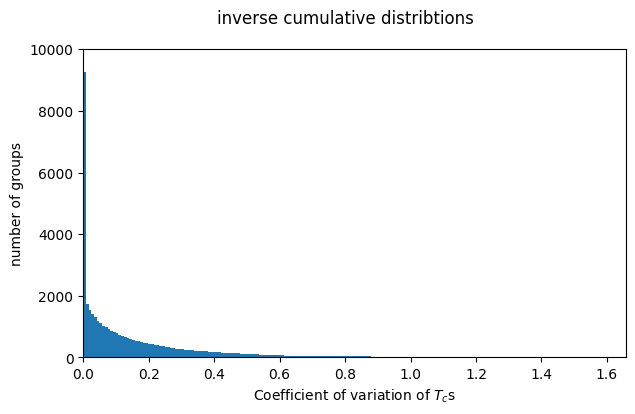

In [69]:
import matplotlib.pyplot as plt

group_cv_data = groups_df['cv'].to_numpy()
entry_cv_data = dataset._df['cv'].to_numpy()

n_bins = 200

fig = plt.figure(figsize=(7, 4))
ax = fig.subplots(1, 1, sharex=True)

#axs[0].ecdf(entry_cv_data)
#axs[1].ecdf(group_cv_data)

n, bins, patches = ax.hist(group_cv_data, n_bins, density = False, histtype='bar', cumulative=-1, label='Cumulative Histogram')
ax.set_ybound(0, 2000*(1+len(group_cv_data)//2000))
ax.set_xbound(group_cv_data.min(), group_cv_data.max())
ax.set_ylabel(r'number of groups')

# n, bins, patches = axs[1].hist(entry_cv_data, n_bins, density = False, histtype='bar', cumulative=-1, label='Cumulative Histogram2')
# axs[1].set_ybound(0, len(entry_cv_data))
# axs[1].set_xbound(entry_cv_data.min(), entry_cv_data.max())
# axs[1].set_ylabel(r'number of entries')
ax.set_xlabel(r'Coefficient of variation of $T_c$s')


# for ax in axs:
#     #ax.grid(True)
#     #ax.legend()
#     ax.label_outer()
fig.suptitle("inverse cumulative distribtions")
fig.savefig("icdf.svg", format='svg')
fig.show()

 # 그룹 내 tc 편차가 큰 그룹 처리:
 * 'shape'가 bulk인 경우(1, 2, 3)를 다시 group지어 봅니다.
 * Note: SuperCon 문서에서
     >shape: sample form (1: single phase(bulk),2: multi phase(bulk),3: single crystal(bulk) ,4:film,5:film(single))

In [70]:
shapes = [[dataset._df.loc[i, 'shape'] for i in row['members']] for _, row in groups_df.iterrows()]
group_tcs = [[dataset._df.loc[i, 'tc'] for i in row['members']] for _, row in groups_df.iterrows()]

groups_df['bulk_tcs']=[[tc for tc, s in zip(tc_list, shape_list) if s in (1, 2, 3)] for tc_list, shape_list in zip(group_tcs, shapes)]
groups_bulk_df = groups_df.loc[groups_df['bulk_tcs'].apply(lambda x: len(x)>0)]['bulk_tcs'].copy().to_frame()
groups_df = groups_df.drop(columns=['bulk_tcs'])

In [71]:
groups_bulk_df['max_bulk']=groups_bulk_df['bulk_tcs'].apply(lambda x: np.max([float(i) for i in x]))
groups_bulk_df['min_bulk']=groups_bulk_df['bulk_tcs'].apply(lambda x: np.min([float(i) for i in x]))

groups_bulk_df['mean_bulk']=groups_bulk_df['bulk_tcs'].apply(lambda x: np.mean([float(i) for i in x]))
groups_bulk_df['std_bulk']=groups_bulk_df['bulk_tcs'].apply(lambda x: np.std([float(i) for i in x]))
groups_bulk_df['cv_bulk']=groups_bulk_df['std_bulk']/groups_bulk_df['mean_bulk']
groups_bulk_df

,bulk_tcs,max_bulk,min_bulk,mean_bulk,std_bulk,cv_bulk
0,"[35.1, 34.0, 37.0, 37.0, 36.4, 37.0, 37.2, 35....",45.30,0.001,28.981392,8.683774,0.299633
8,"[43.0, 40.7, 40.6, 40.8, 42.0, 43.0, 43.0, 43....",43.00,39.900,41.991667,1.136851,0.027073
9,[36.9],36.90,36.900,36.900000,0.000000,0.000000
15,[14.4],14.40,14.400,14.400000,0.000000,0.000000
17,[31.9],31.90,31.900,31.900000,0.000000,0.000000
...,...,...,...,...,...,...
9329,[2.1],2.10,2.100,2.100000,0.000000,0.000000
9330,[1.63],1.63,1.630,1.630000,0.000000,0.000000
9334,[116.0],116.00,116.000,116.000000,0.000000,0.000000
9335,[34.5],34.50,34.500,34.500000,0.000000,0.000000


 ## 그룹 내 명시적으로 Bulk인 것들의 통계

In [72]:
groups_df_merged=pd.concat([groups_df, groups_bulk_df], axis=1, join="outer")
assert all(groups_df_merged.index==groups_df.index)
groups_df_merged

,size,members,tcs,min,max,mean,std,cv,bulk_tcs,max_bulk,min_bulk,mean_bulk,std_bulk,cv_bulk
0,358,"[1, 5, 27, 39, 50, 74, 95, 108, 122, 133, 144,...","[39, 34.7, 36, 39.3, 37.1, 40, 39, 28.6, 35, 3...",0.001,45.30,29.598858,8.416675,0.284358,"[35.1, 34.0, 37.0, 37.0, 36.4, 37.0, 37.2, 35....",45.30,0.001,28.981392,8.683774,0.299633
6,1,[813],[26.4],26.400,26.40,26.400000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
7,1,[968],[42.4],42.400,42.40,42.400000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
8,21,"[969, 1300, 1322, 1323, 1324, 2029, 2437, 2442...","[42.5, 43.0, 40.7, 40.6, 40.8, 42.0, 42.0, 42....",39.900,43.00,42.242857,0.951476,0.022524,"[43.0, 40.7, 40.6, 40.8, 42.0, 43.0, 43.0, 43....",43.00,39.900,41.991667,1.136851,0.027073
9,2,"[970, 12075]","[42.4, 36.9]",36.900,42.40,39.650000,2.750000,0.069357,[36.9],36.90,36.900,36.900000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9351,1,[11305],[6.5],6.500,6.50,6.500000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
9352,1,[11234],[3.48],3.480,3.48,3.480000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
9353,1,[17381],[5.1],5.100,5.10,5.100000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
9354,1,[17380],[7.2],7.200,7.20,7.200000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


 ## Dataset에 cv_bulk 반영, 분석
 * For example, there are 506 rows of which $cv>0.2$ and $group\_cv<0.2$

In [73]:
dataset._df['cv_bulk']=[groups_df_merged.loc[group_idx, 'cv_bulk'] for _, group_idx in idx_to_group.items()]
dataset._df

,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,Fe,Ir,Rh,Co,Pt,Pd,Ni,Au,Ag,Cu,Hg,Cd,Zn,Tl,In,Ga,Al,B,Pb,Sn,Ge,Si,C,Bi,Sb,As,P,N,H,Te,Se,S,O,I,Br,Cl,F,duplicates_group,cv,cv_bulk
0,23,JJP0260151,NaN,"(La,Ba)2CuO4",La1.85Ba0.15Cu1O4,La,1.85,Ba,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,99,0.284358,0.299633
1,24,JJP0260196,NaN,"(La,Sr)2CuO4",La1.85Sr0.15Cu1O4,La,1.85,Sr,0.15,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,0,0.284358,0.299633
2,99,JJP0260325,NaN,NaN,Lu1.8Ba0.2Cu1O4,Lu,1.8,Ba,0.2,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,4417,0.284358,0.299633
3,100,JJP0260325,NaN,NaN,Y0.9Ba0.1Cu1O4,Y,0.9,Ba,0.1,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.666667,0.0,0.0,0.0,0.0,20,0.284358,0.299633
4,105,APL0500543,NaN,"(La,Ba)2CuO4",Ba0.15La1.85Cu1O4,Ba,0.15,La,1.85,Cu,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,4,NaN,NaN,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.571429,0.0,0.0,0.0,0.0,99,0.284358,0.299633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17377,159087,AIP01115011,Coincident of the onset of the magnetic intera...,FeSr2YCu2O7.57,Fe1Sr2Y1Cu2O7.57,Fe,1.0,Sr,2.0,Y,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,7.57,NaN,1.0,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.073692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.147384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.557848,0.0,0.0,0.0,0.0,4735,0.000000,NaN
17378,159088,NAL02003808,"In an atomically ultrathin of TaS2, incorporat...",TaS2,Ta1S2,Ta,1.0,S,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.666667,0.000000,0.0,0.0,0.0,0.0,1678,0.000000,NaN
17379,159089,MAT00302055,"By an angle-resolved photoemission spectropy, ...",TaSe3,Ta1Se3,Ta,1.0,Se,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.000000,0.000000,0.0,0.0,0.0,0.0,1914,0.000000,NaN
17380,159090,AFM0312007960,New superconductor NbIr2B2 shows Tc of 7.2K wi...,NbIr2B2,Nb1Ir2B2,Nb,1.0,Ir,2.0,B,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,2020,NaN,NaN

In [74]:
dataset._df[(dataset._df['cv']>0.2) & (dataset._df['cv_bulk']<0.2)].sort_values(by='cv_bulk', ascending=False)

,num,refno,commt,name,element,ma1,ma2,mb1,mb2,mc1,mc2,md1,md2,me1,me2,mf1,mf2,mg1,mg2,mh1,mh2,mi1,mi2,mj1,mj2,mo1,mo2,oz,shape,year,ukai,kaizero,ucc,curiec,umoment,moment,curiet,neelt,dens,uhv,...,Fe,Ir,Rh,Co,Pt,Pd,Ni,Au,Ag,Cu,Hg,Cd,Zn,Tl,In,Ga,Al,B,Pb,Sn,Ge,Si,C,Bi,Sb,As,P,N,H,Te,Se,S,O,I,Br,Cl,F,duplicates_group,cv,cv_bulk
3064,33920,L090137001,P-induced SC. s/c and NMR measurements at P=3....,"(Sr,Ca)14Cu24O41",Sr2Ca12Cu24O41,Sr,2.0,Ca,12.0,Cu,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,41,NaN,3.0,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303797,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.518987,0.0,0.0,0.0,0.0,1520,1.097325,0.182884
3065,33921,L090137002,heavily underdoped sample. anisotropy=600 (T=0...,Bi2Sr2CaCu2O8,Bi2Sr2Ca1Cu2O8,Bi,2.0,Sr,2.0,Ca,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,8,NaN,3.0,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.533333,0.0,0.0,0.0,0.0,60,1.097325,0.182884
3066,33922,PRL0842945,slightly underdoped. anisotropy=550.,Bi2Sr2CaCu2O8,Bi2Sr2Ca1Cu2O8,Bi,2.0,Sr,2.0,Ca,1.0,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,8,NaN,3.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.533333,0.0,0.0,0.0,0.0,60,1.097325,0.182884
3063,33919,EPL0580758,pressure-induced s/c. critical-P = 3.5 GPa. Tc...,"(Sr,Ca)14Cu24O41",Sr11Ca12Cu24O41,Sr,11.0,Ca,12.0,Cu,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,41,NaN,3.0,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.272727,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.465909,0.0,0.0,0.0,0.0,1523,1.097325,0.182884
3048,33883,P067092504,thickness=600A,"Bi2Sr2(Ca,Sr)Cu2O8",Bi2Sr2.65Ca0.35Cu2O8,Bi,2.0,Sr,2.65,Ca,0.35,Cu,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,8,NaN,5.0,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.533333,0.0,0.0,0.0,0.0,76,1.097325,0.182884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5134,101185,115,NaN,Er0.01La0.99,Er0.01La0.99,Er,0.01,La,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1958.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5372,0.413607,0.000000
5135,101187,115,NaN,Dy0.01La0.99,Dy0.01La0.99,Dy,0.01,La,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1958.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,8136,0.413607,0.000000
5431,101649,1240,NaN,La1Tl3,La1Tl3,La,1.0,Tl,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1968.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,4974,0.369239,0.000000
5432,101650,1564,NaN,La3Tl1,La3Tl1,La,3.0,Tl,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

### (To choose threshold) The CoV of Tcs of the HE-SC dataset

In [75]:
import json
from pathlib import Path
with open(Path('../temp_devs/compositional5_max_tc.log.json')) as file:
    log274 = json.load(file)

from hsdu.dataset import Dataset
hsd = Dataset('../src/hsdu/data/dataset_0811.csv', exception_col=None)
hsd.column_sets['tc_cols']

['Tc(K).resistivity.mid',
 'Tc(K).magnetization.mid',
 'Tc(K).resistivity.None',
 'Tc(K).magnetization.onset',
 'Tc(K).magnetization.None',
 'Tc(K).resistivity.zero',
 'Tc(K).specific_heat.mid',
 'Tc(K).other.None',
 'Tc(K).resistivity.onset',
 'Tc(K).specific_heat.onset',
 'Tc(K).specific_heat.None',
 'Tc(K).magnetization.zero',
 'Tc(K).other.onset',
 'Tc(K).other.mid',
 'Tc(K).specific_heat.zero']

In [80]:
from hsdu.utils.conversion_utils import process_targets
target_df = process_targets(hsd._df, targets=hsd.config['targets'], exception_row=None, add_tcs_col=True)
target_df

no valid tc parsed. assign Tc=0 for row_idx: 8, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 9, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 10, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 12, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 14, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 16, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 17, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 18, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 23, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no valid tc parsed. assign Tc=0 for row_idx: 58, comp:unknown comps, tcs:[], not_passed_tc_cols: []
no

,max_Tc,min_Tc,avg_Tc,tcs
0,0.82,0.82,0.820000,[0.82]
1,1.06,1.06,1.060000,[1.06]
2,1.38,1.38,1.380000,[1.38]
3,1.61,1.61,1.610000,[1.61]
4,6.13,5.30,5.715000,"[6.13, 5.3]"
...,...,...,...,...
463,4.52,3.44,3.956667,"[4.52, 3.91, 3.44]"
464,4.20,2.88,3.500000,"[4.2, 3.42, 2.88]"
465,4.94,3.88,4.403333,"[4.94, 4.39, 3.88]"
466,4.77,3.39,4.100000,"[4.77, 4.14, 3.39]"


In [81]:
cvs = [] # coefficient of variations
for k, v in log274['duplicated_comps'].items():
    all_tcs = []
    for i in v.keys():
        all_tcs.extend(target_df.loc[int(i), 'tcs'])
    #print(all_tcs)
    cvs.append(np.std(all_tcs)/np.mean(all_tcs))
cvs = np.array(cvs)
cvs = cvs[~np.isnan(cvs)]

/home/chhyyi/hsd_utils/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/chhyyi/hsd_utils/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning:

invalid value encountered in divide

/home/chhyyi/hsd_utils/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning:

invalid value encountered in scalar divide

/home/chhyyi/hsd_utils/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning:

Mean of empty slice

/home/chhyyi/hsd_utils/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning:

invalid value encountered in scalar divide



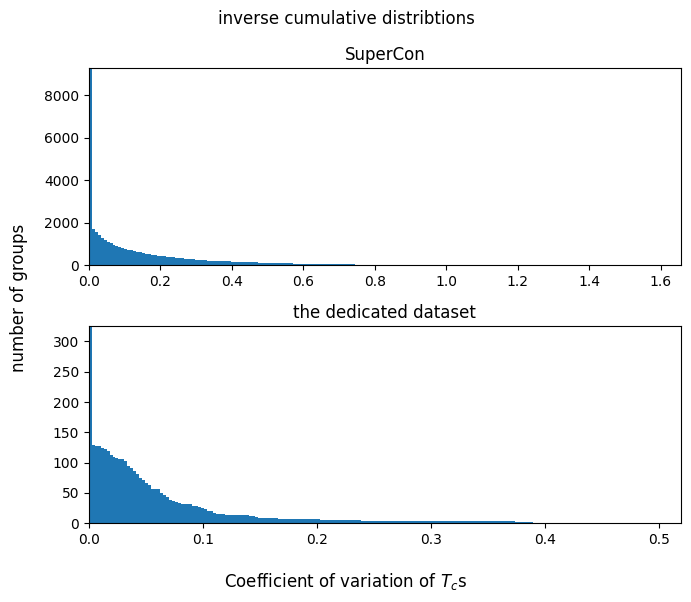

In [82]:
n_bins = 200
group_cv_data = groups_df['cv'].to_numpy()

fig = plt.figure(figsize=(7, 6))
axes = fig.subplots(2, 1, sharex=False)

cv_list = [group_cv_data, cvs]
titles = ['SuperCon', 'the dedicated dataset']

for cv, ax, title in zip(cv_list, axes, titles):
    n, bins, patches = ax.hist(cv, n_bins, density = False, histtype='bar', cumulative=-1)
    ax.set_ybound(0, len(cv))
    ax.set_xbound(cv.min(), cv.max())
    ax.set_title(title)
fig.supylabel(r'number of groups')

fig.supxlabel(r'Coefficient of variation of $T_c$s')

fig.suptitle("inverse cumulative distribtions")
plt.tight_layout()
fig.savefig("icdf_hesc_cv.svg", format='svg')
fig.show()

 ## Export preprocessed_supercon.csv
 * 'tc'로 어떤 값을 쓸지, 어떻게 합칠지 특별히 기준을 찾을 수 없었습니다.
 * 그러므로, 산출한 stat들을 모두 export하도록 합니다.
 * composition: pymatgen Composition의 `to_pretty_string` 메서드를 이용합니다.

In [ ]:
group_comps_df=pd.DataFrame()
group_comps_df['comps_pymatgen_list']={index:[dataset._df.loc[m, 'comps_pymatgen'] for m in members] for index, members in groups_df_merged['members'].items()}

group_comps_df['mean_composition']=group_comps_df['comps_pymatgen_list'].apply(lambda x: sum(x, start=Composition())/len(x))
group_comps_df['mean_comps_string']=group_comps_df['mean_composition'].apply(lambda x: x.to_pretty_string())
group_comps_df['mean_comps_dict']=group_comps_df['mean_composition'].apply(lambda x: x.as_dict())
assert all(group_comps_df.index==groups_df_merged.index)
group_comps_df

,comps_pymatgen_list,mean_composition,mean_comps_string,mean_comps_dict
0,"[(La, Sr, Cu, O), (Sr, La, Cu, O), (La, Sr, Cu...","(La, Sr, Cu, O)",La1.84234358Sr0.15781285Cu0.9999162O4.00011173,"{'La': 1.8423435754189919, 'Sr': 0.15781284916..."
6,"[(La, Sr, Cu, O)]","(La, Sr, Cu, O)",La1.87Sr0.125Cu1.07O4,"{'La': 1.87, 'Sr': 0.125, 'Cu': 1.07, 'O': 4.0}"
7,"[(Sr, La, Cu, O)]","(Sr, La, Cu, O)",Sr0.95La0.05Cu1O2,"{'Sr': 0.95, 'La': 0.05, 'Cu': 1.0, 'O': 2.0}"
8,"[(Sr, La, Cu, O), (Sr, La, Cu, O), (Sr, La, Cu...","(Sr, La, Cu, O)",Sr0.9La0.1Cu1O2,"{'Sr': 0.8999999999999999, 'La': 0.10000000000..."
9,"[(Sr, La, Cu, O), (Sr, La, Cu, O)]","(Sr, La, Cu, O)",Sr0.8775La0.1225Cu1O2,"{'Sr': 0.8775, 'La': 0.1225, 'Cu': 1.0, 'O': 2.0}"
...,...,...,...,...
9351,"[(As, La)]","(As, La)",As3La4,"{'As': 3.0, 'La': 4.0}"
9352,"[(H, Nb, Pd, W)]","(H, Nb, Pd, W)",H0.47Nb0.72Pd0.18W0.1,"{'H': 0.47, 'Nb': 0.72, 'Pd': 0.18, 'W': 0.1}"
9353,"[(Ta, Ir, B)]","(Ta, Ir, B)",Ta1Ir2B2,"{'Ta': 1.0, 'Ir': 2.0, 'B': 2.0}"
9354,"[(Nb, Ir, B)]","(Nb, Ir, B)",Nb1Ir2B2,"{'Nb': 1.0, 'Ir': 2.0, 'B': 2.0}"


 ### 쓸만한 정보들을 조금 추가하고 export 합니다.

In [ ]:
out_df = pd.concat([groups_df_merged, group_comps_df], axis=1)
out_df['supercon_num'] = [[data.loc[idx_to_supercon_idx[i],'num'] for i in members] for members in groups_df_merged['members']]
rename_dicts = {old:old+'_tcs' for old in ['min', 'max', 'mean', 'std', 'cv', 'max_bulk', 'min_bulk', 'mean_bulk', 'std_bulk', 'cv_bulk']}
rename_dicts['size']='group_size'
out_df=out_df.rename(columns=rename_dicts)

# columns order:
out_df=out_df[['group_size', 'members', 'mean_comps_string', 'mean_comps_dict', 'supercon_num', 'tcs', 'min_tcs', 'max_tcs', 'mean_tcs', 'std_tcs',
            'cv_tcs', 'bulk_tcs', 'max_bulk_tcs', 'min_bulk_tcs', 'mean_bulk_tcs',
            'std_bulk_tcs', 'cv_bulk_tcs']]
out_df.to_csv('supercon_merge_dupls_20260813.csv', index_label='group_id')

 ## Featurize (독립적으로 실행 가능)
 메모리를 정리 안해서 그런지 죽어버리는 경우가 있어, 모듈을 불러오는 것부터 따로 실행 가능하게 분리합니다.

In [1]:
import warnings
from pandas.errors import PerformanceWarning

# 1. matminer의 impute_nan 관련 UserWarning 무시
warnings.filterwarnings(
    action='ignore', 
    category=UserWarning, 
    module='matminer'
)

# 2. pandas의 DataFrame 파편화 PerformanceWarning 무시
warnings.filterwarnings(
    action='ignore', 
    category=PerformanceWarning
)

In [2]:
import pandas as pd
from matminer.featurizers.base import MultipleFeaturizer

from hsdu.dataset import D2TableDataset
from hsdu.preprocess.utils import featurizer_config_loader

cleaned = D2TableDataset("../reproduce/supercon_merge_dupls_20260813.csv", exception_col=None, parse_pymatgen_comps_col='mean_comps_string', index_col=None)
cleaned.normalize_fractions(inplace=True)
cleaned._df

,group_id,group_size,members,mean_comps_string,mean_comps_dict,supercon_num,tcs,min_tcs,max_tcs,mean_tcs,...,N,H,Te,Se,S,O,I,Br,Cl,F
0,0,358,"[1, 5, 27, 39, 50, 74, 95, 108, 122, 133, 144,...",La1.84234358Sr0.15781285Cu0.9999162O4.00011173,"{'La': 1.8423435754189919, 'Sr': 0.15781284916...","['24', '106', '133', '187', '230', '377', '661...","['39', '34.7', '36', '39.3', '37.1', '40', '39...",0.001,45.30,29.598858,...,0.0,0.000000,0.0,0.0,0.0,0.571429,0.0,0.0,0.0,0.0
1,6,1,[813],La1.87Sr0.125Cu1.07O4,"{'La': 1.87, 'Sr': 0.125, 'Cu': 1.07, 'O': 4.0}",['3188'],['26.4'],26.400,26.40,26.400000,...,0.0,0.000000,0.0,0.0,0.0,0.566171,0.0,0.0,0.0,0.0
2,7,1,[968],Sr0.95La0.05Cu1O2,"{'Sr': 0.95, 'La': 0.05, 'Cu': 1.0, 'O': 2.0}",['3613'],['42.4'],42.400,42.40,42.400000,...,0.0,0.000000,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,0.0
3,8,21,"[969, 1300, 1322, 1323, 1324, 2029, 2437, 2442...",Sr0.9La0.1Cu1O2,"{'Sr': 0.8999999999999999, 'La': 0.10000000000...","['3614', 4753, 4790, 4791, 4792, 8971, 10620, ...","['42.5', 43.0, 40.7, 40.6, 40.8, 42.0, 42.0, 4...",39.900,43.00,42.242857,...,0.0,0.000000,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,0.0
4,9,2,"[970, 12075]",Sr0.8775La0.1225Cu1O2,"{'Sr': 0.8775, 'La': 0.1225, 'Cu': 1.0, 'O': 2.0}","['3615', 150673]","['42.4', 36.9]",36.900,42.40,39.650000,...,0.0,0.000000,0.0,0.0,0.0,0.500000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9248,9351,1,[11305],As3La4,"{'As': 3.0, 'La': 4.0}",[131395],[6.5],6.500,6.50,6.500000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9249,9352,1,[11234],H0.47Nb0.72Pd0.18W0.1,"{'H': 0.47, 'Nb': 0.72, 'Pd': 0.18, 'W': 0.1}",[131312],[3.48],3.480,3.48,3.480000,...,0.0,0.319728,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9250,9353,1,[17381],Ta1Ir2B2,"{'Ta': 1.0, 'Ir': 2.0, 'B': 2.0}",[159091],[5.1],5.100,5.10,5.100000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9251,9354,1,[17380],Nb1Ir2B2,"{'Nb': 1.0, 'Ir': 2.0, 'B': 2.0}",[159090],[7.2],7.200,7.20,7.200000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


### check if normalization required

In [5]:
# matminer_preset
fconfig = "matminer_preset"

featurized_df = pd.DataFrame()
featurized_df['comps_pymatgen']=cleaned.idx2aux['comps_pymatgen']

featurizers_list, col_names_df = featurizer_config_loader(config=fconfig)
featurizer = MultipleFeaturizer(featurizers_list)
featurizer.featurize_dataframe(featurized_df, col_id='comps_pymatgen', inplace=True)

# comps_pymatgen column is a Composition object so drop or get string.
featurized_df['comps_pymatgen']=featurized_df['comps_pymatgen'].apply(lambda x:x.to_pretty_string())

#assert len(cleaned._df)==len(featurized_df)
out_df = pd.concat([cleaned._df.reset_index(drop=True), featurized_df.reset_index(drop=True)], axis=1)
out_df.to_csv(f'supercon_{fconfig}.csv', index=False)
col_names_df.to_json(f'supercon_{fconfig}_features_list.json', orient='index', indent=4)

MultipleFeaturizer:   0%|          | 0/9253 [00:00<?, ?it/s]

In [6]:
# matminer_preset
fconfig = "comp449"

featurized_df = pd.DataFrame()
featurized_df['comps_pymatgen']=cleaned.idx2aux['comps_pymatgen']

featurizers_list, col_names_df = featurizer_config_loader(config=fconfig)
featurizer = MultipleFeaturizer(featurizers_list)
featurizer.featurize_dataframe(featurized_df, col_id='comps_pymatgen', inplace=True)

# comps_pymatgen column is a Composition object so drop or get string.
featurized_df['comps_pymatgen']=featurized_df['comps_pymatgen'].apply(lambda x:x.to_pretty_string())

#assert len(cleaned._df)==len(featurized_df)
out_df = pd.concat([cleaned._df.reset_index(drop=True), featurized_df.reset_index(drop=True)], axis=1)
out_df.to_csv(f'supercon_{fconfig}.csv', index=False)
col_names_df.to_json(f'supercon_{fconfig}_features_list.json', orient='index', indent=4)

/home/chhyyi/hsd_utils/src/hsdu/data/vendor/matminer/data.py:140: UserWarning: MastMLMagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
/home/chhyyi/hsd_utils/src/hsdu/data/vendor/matminer/data.py:140: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the av

MultipleFeaturizer:   0%|          | 0/9253 [00:00<?, ?it/s]

/home/chhyyi/hsd_utils/src/hsdu/preprocess/feature.py:543: UserWarning: some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.
  warnings.warn("some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.")
/home/chhyyi/hsd_utils/src/hsdu/preprocess/feature.py:543: UserWarning: some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.
  warnings.warn("some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.")
/home/chhyyi/hsd_utils/src/hsdu/preprocess/feature.py:543: UserWarning: some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.
  warnings.warn("some elemental properties are negative. In this case, AP is not clearly defined. using |f_i-f_j|/(|f_i|+|f_j|) instead.")
/home/c